# Exploratory Data Analysis (EDA) - Telecommunication companies

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


### Check for null values 

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Look for the overall information about dataset

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#
----

### 1. Overall churn distribution

Churn Distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


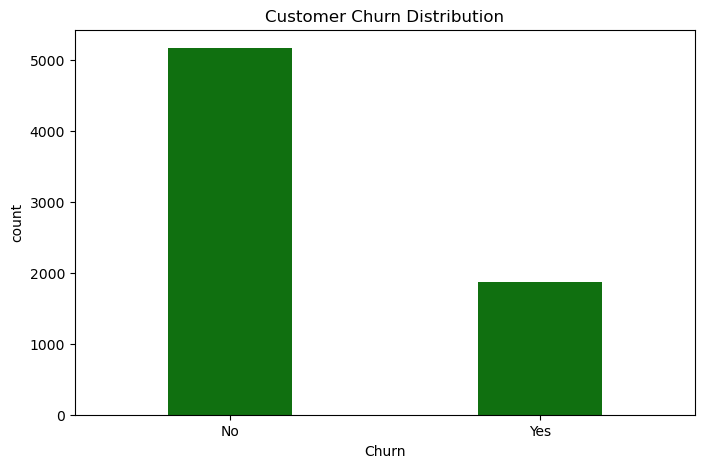

In [37]:
print("Churn Distribution:")
print(df['Churn'].value_counts(normalize=True)*100)
plt.figure(figsize=(8,5))
sns.countplot(x='Churn', data=df,width=0.4,color='green')
plt.title("Customer Churn Distribution")
plt.show()

- Most customers stay with the company, but a noticeable portion leave the service.
- Around 1 out of every 4 customers churns, which is a significant loss for the business.
- The company is losing a large number of customers every year, so improving retention can save a lot of money.

#
---

### 2. Tenure vs Churn

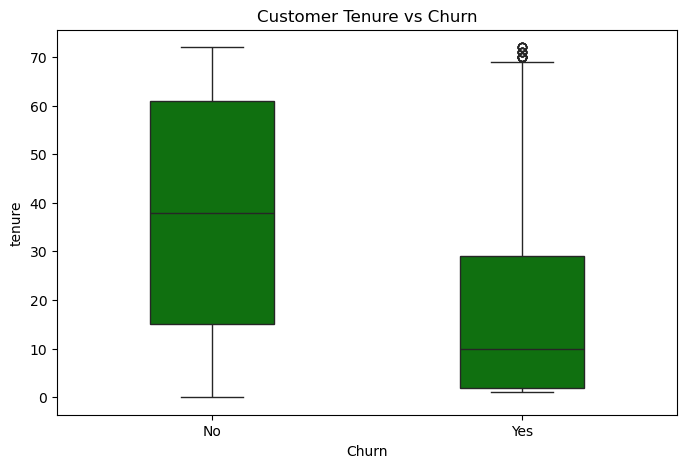

Average tenure by churn:
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df,color='green',width=0.4)
plt.title("Customer Tenure vs Churn")
plt.show()

print("Average tenure by churn:")
print(df.groupby('Churn')['tenure'].mean())


- Month-to-month customers churn the most.
- Customers with 1-year or 2-year contracts rarely leave.
- When customers are not tied to a contract, they can easily switch to another provider.

#
---

### 3. Contract type vs Churn

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


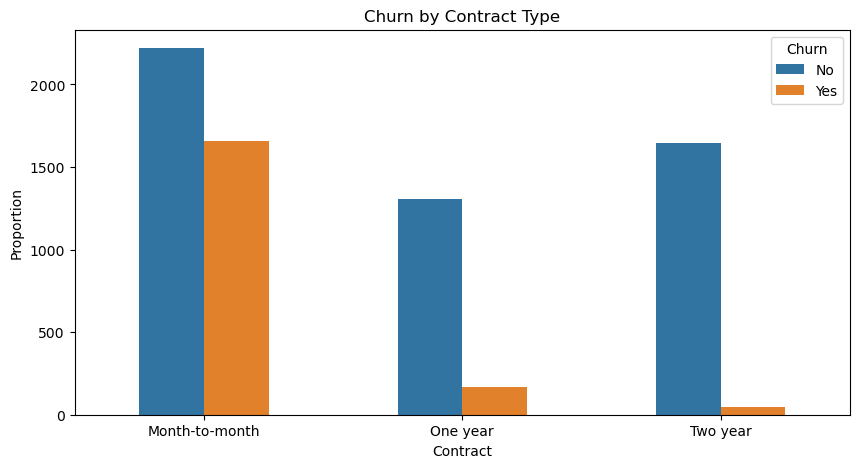

In [95]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
print(contract_churn)
plt.figure(figsize=(10,5))
sns.countplot(x='Contract', hue='Churn', data=df,width=0.5)
plt.title("Churn by Contract Type")
plt.ylabel("Proportion")
plt.show()

#
---

### 4. Internet Service vs Churn

Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050


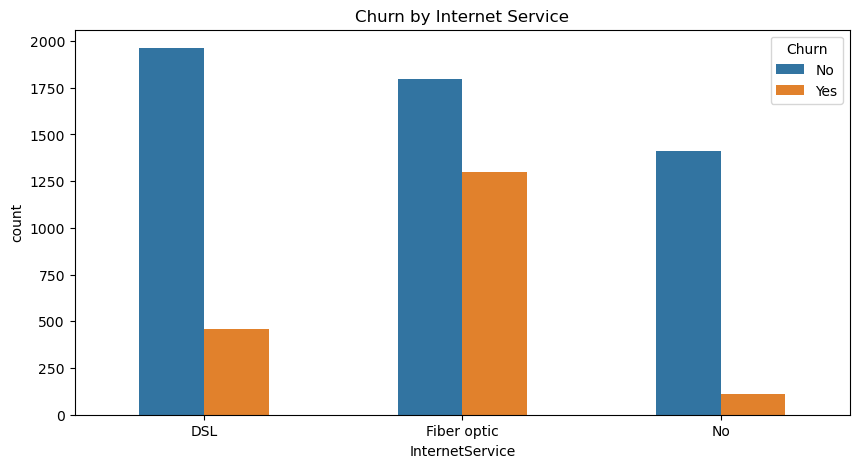

In [97]:
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
print(internet_churn)
plt.figure(figsize=(10,5))
sns.countplot(x='InternetService', hue='Churn', data=df,width=0.5)
plt.title("Churn by Internet Service")
plt.show()

- Fiber optic customers churn the most.
- DSL customers churn less.
- Customers without internet service have very low churn.
- Fiber users may have higher expectations or may find cheaper alternatives.

#
---

### 5. Monthly Charges vs Churn

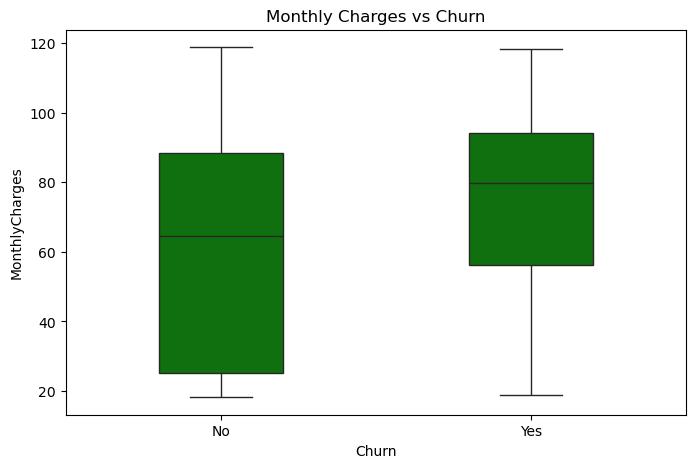

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [105]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,color='green',width=0.4)
plt.title("Monthly Charges vs Churn")
plt.show()
print(df.groupby('Churn')['MonthlyCharges'].mean())

- Customers who pay higher monthly bills are more likely to leave.
- When the service becomes too expensive, customers start looking for cheaper options.

#
---

### 6. Payment Method vs Churn

Churn                            No       Yes
PaymentMethod                                
Bank transfer (automatic)  0.832902  0.167098
Credit card (automatic)    0.847569  0.152431
Electronic check           0.547146  0.452854
Mailed check               0.808933  0.191067


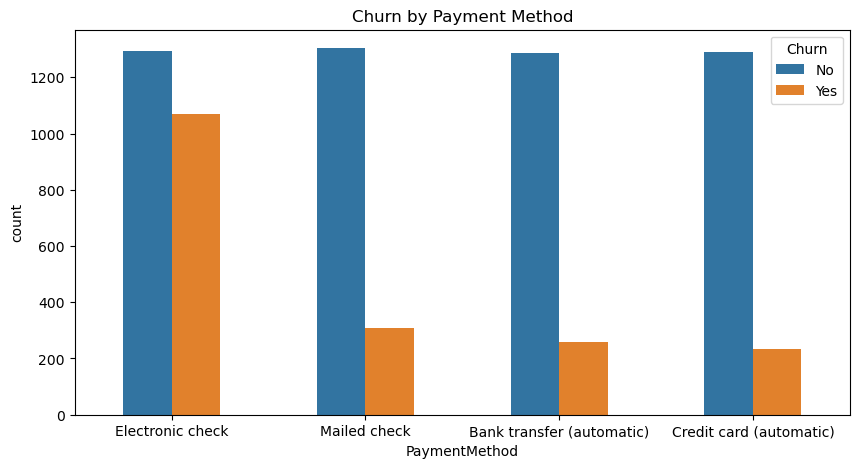

In [119]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')
print(payment_churn)
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df,width=0.5)
plt.title("Churn by Payment Method")
plt.show()

- Customers using electronic check have the highest churn rate.
- Customers with automatic payments (bank transfer or credit card) churn less.
- Automatic payments indicate higher commitment and convenience.

#
---

### 7. Paperless Billing vs Churn

Churn                   No       Yes
PaperlessBilling                    
No                0.836699  0.163301
Yes               0.664349  0.335651


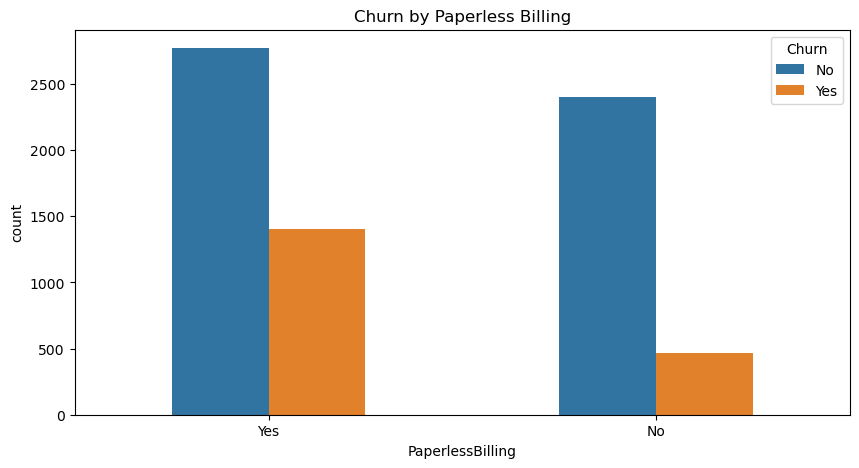

In [128]:
paperless_churn = pd.crosstab(df['PaperlessBilling'], df['Churn'], normalize='index')
print(paperless_churn)
plt.figure(figsize=(10,5))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df, width=0.5)
plt.title("Churn by Paperless Billing")
plt.show()


- Customers using paperless billing churn slightly more.
- Digital customers may switch providers more easily online.

#
---

### 8. Senior Citizen vs Churn

Churn                No       Yes
SeniorCitizen                    
0              0.763938  0.236062
1              0.583187  0.416813


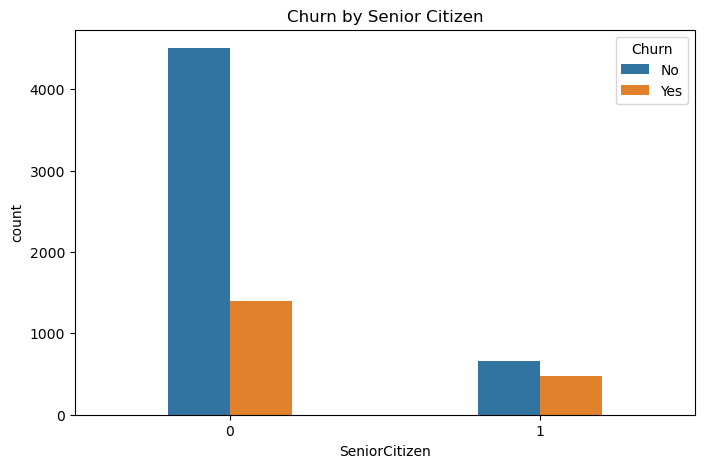

In [137]:
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')
print(senior_churn)
plt.figure(figsize=(8,5))
sns.countplot(x='SeniorCitizen', hue='Churn',data=df,width=0.4)
plt.title("Churn by Senior Citizen")
plt.show()

- Senior citizens churn slightly more than younger customers.
- Older customers may be more sensitive to price or service issues.